# 04 — Platform-Level Content Strategy Analysis (Part I)

In this notebook, we will analyze **one streaming platform at a time** and translate charts into a short, insight-driven narrative about that platform’s **content identity**.

**What you'll do**
- Filter content to a single platform (e.g., Netflix, Prime Video, Hulu, Disney+)
- Visualize platform-specific patterns:
  - Genre mix
  - Release year distribution
  - Movie vs TV focus (from the combined dataset)
  - (Optional) IMDb / RottenTomatoes score distributions
- Write a brief summary paragraph supported by evidence (your charts)

**Datasets used**
- `MoviesOnStreamingPlatforms_Cleaned.csv`
- `TVShowsOnStreamingPlatforms_Cleaned.csv`


In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Display settings
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)


In [2]:
# Load cleaned datasets
DATA_DIR = Path("/Users/joanna/Desktop/Open Avenues/Data")  # adjust if needed

MOVIES_PATH = DATA_DIR / "MoviesOnStreamingPlatforms_Cleaned.csv"
TV_PATH     = DATA_DIR / "TVShowsOnStreamingPlatforms_Cleaned.csv"

movies = pd.read_csv(MOVIES_PATH)
tv = pd.read_csv(TV_PATH)

print("Movies shape:", movies.shape)
print("TV shape:", tv.shape)

movies.head(3)


Movies shape: (9515, 19)
TV shape: (5368, 19)


,ID,Title,Year,Age,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type,Genre,Country,Language,IMDb,IMDb_ID,RottenTomatoes_Score,Age_Min,Type_raw,Title_key
0,1,The Irishman,2019,18+,98/100,1,0,0,0,movie,"Biography, Crime, Drama",United States,"English, Italian, Latin, Spanish, German",7.8,tt1302006,98.0,18.0,0,the irishman
1,2,Dangal,2016,7+,97/100,1,0,0,0,movie,"Action, Biography, Drama","India, United States","Hindi, English",8.3,tt5074352,97.0,7.0,0,dangal
2,3,David Attenborough: A Life on Our Planet,2020,7+,95/100,1,0,0,0,movie,"Documentary, Biography",United Kingdom,English,8.9,tt11989890,95.0,7.0,0,david attenborough: a life on our planet


## Quick schema check

The cleaned datasets share the same schema. Important columns we will use:
- `Title`, `Year`
- Platform indicators: `Netflix`, `Hulu`, `Prime Video`, `Disney+` (1 = available on that platform)
- `Type` (movie vs tv_show)
- `Genre` (comma-separated for movies, sometimes verbose for TV)
- `IMDb`, `RottenTomatoes_Score`, `Age` / `Age_Min`


In [3]:
movies.columns

Index(['ID', 'Title', 'Year', 'Age', 'Rotten Tomatoes', 'Netflix', 'Hulu', 'Prime Video', 'Disney+', 'Type', 'Genre',
       'Country', 'Language', 'IMDb', 'IMDb_ID', 'RottenTomatoes_Score', 'Age_Min', 'Type_raw', 'Title_key'],
      dtype='object')

In [4]:
# Combine into one content table (movies + tv)
movies2 = movies.copy()
tv2 = tv.copy()

df = pd.concat([movies2, tv2], ignore_index=True)

# Basic sanity checks
df[["Title", "Year", "Type", "Netflix", "Hulu", "Prime Video", "Disney+", "Type"]].head()


,Title,Year,Type,Netflix,Hulu,Prime Video,Disney+,Type
0,The Irishman,2019,movie,1,0,0,0,movie
1,Dangal,2016,movie,1,0,0,0,movie
2,David Attenborough: A Life on Our Planet,2020,movie,1,0,0,0,movie
3,Lagaan: Once Upon a Time in India,2001,movie,1,0,0,0,movie
4,Roma,2018,movie,1,0,0,0,movie


## Reshape to a platform-level view (long format)

Right now, each row has 4 platform indicator columns.  
For platform analysis, it's convenient to convert the dataset into a **long format** where each title appears once per platform it belongs to.


In [5]:
platform_cols = ["Netflix", "Hulu", "Prime Video", "Disney+"]

def to_long_platform(df_in: pd.DataFrame) -> pd.DataFrame:
    base_cols = [c for c in df_in.columns if c not in platform_cols]

    # Melt platform indicator columns into rows
    melted = df_in.melt(
        id_vars=base_cols,
        value_vars=platform_cols,
        var_name="platform",
        value_name="on_platform"
    )

    # Keep only records where on_platform == 1
    long_df = melted[melted["on_platform"] == 1].drop(columns=["on_platform"])
    return long_df

df_long = to_long_platform(df)

print("Original rows:", len(df))
print("Long rows (one per platform):", len(df_long))
df_long[["Title", "Year", "Type", "platform", "Genre", "IMDb", "RottenTomatoes_Score"]].head()


Original rows: 14883
Long rows (one per platform): 15551


,Title,Year,Type,platform,Genre,IMDb,RottenTomatoes_Score
0,The Irishman,2019,movie,Netflix,"Biography, Crime, Drama",7.8,98.0
1,Dangal,2016,movie,Netflix,"Action, Biography, Drama",8.3,97.0
2,David Attenborough: A Life on Our Planet,2020,movie,Netflix,"Documentary, Biography",8.9,95.0
3,Lagaan: Once Upon a Time in India,2001,movie,Netflix,"Drama, Musical, Sport",8.1,94.0
4,Roma,2018,movie,Netflix,Drama,7.6,94.0


## Choose ONE platform to analyze

During the live demo, start with one platform (e.g., **Netflix**).  
Then students can repeat the same analysis for another platform in the exercise.


In [6]:
PLATFORM = "Netflix"   # change to: "Hulu", "Prime Video", "Disney+"
platform_df = df_long[df_long["platform"] == PLATFORM].copy()

print("Platform:", PLATFORM)
print("Rows:", platform_df.shape)
platform_df.head(3)

Platform: Netflix
Rows: (5666, 16)


,ID,Title,Year,Age,Rotten Tomatoes,Type,Genre,Country,Language,IMDb,IMDb_ID,RottenTomatoes_Score,Age_Min,Type_raw,Title_key,platform
0,1,The Irishman,2019,18+,98/100,movie,"Biography, Crime, Drama",United States,"English, Italian, Latin, Spanish, German",7.8,tt1302006,98.0,18.0,0,the irishman,Netflix
1,2,Dangal,2016,7+,97/100,movie,"Action, Biography, Drama","India, United States","Hindi, English",8.3,tt5074352,97.0,7.0,0,dangal,Netflix
2,3,David Attenborough: A Life on Our Planet,2020,7+,95/100,movie,"Documentary, Biography",United Kingdom,English,8.9,tt11989890,95.0,7.0,0,david attenborough: a life on our planet,Netflix


## 1) Movie vs TV focus

A quick way to understand platform positioning: does it lean toward movies or TV?


In [7]:
type_counts = platform_df["Type"].value_counts()

type_counts

Type
movie      3695
tv_show    1971
Name: count, dtype: int64

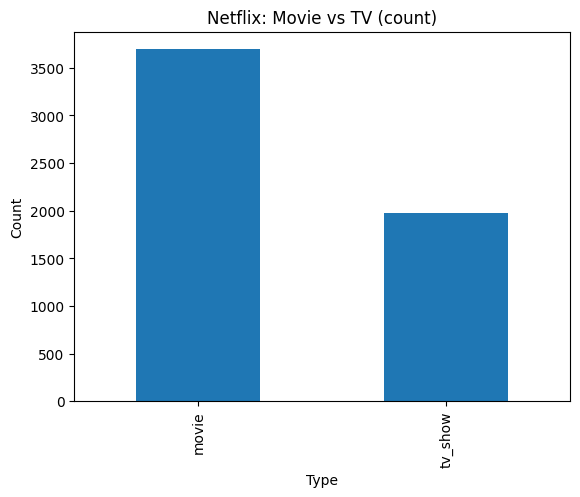

In [8]:
type_counts.plot(kind="bar")
plt.title(f"{PLATFORM}: Movie vs TV (count)")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()


## 2) Genre mix (Top 10)

Genres are stored in a text field. For movies it's comma-separated; for TV it can be a verbose label.
We'll use a simple approach:
- split by comma (if present)
- trim whitespace
- count genres


In [9]:
def top_genres(df_in: pd.DataFrame, top_n: int = 10) -> pd.Series:
    g = df_in["Genre"].dropna().astype(str)
    # split on comma; if no comma, this still returns a single-item list
    exploded = g.str.split(",").explode().str.strip()
    exploded = exploded[exploded != ""]
    return exploded.value_counts().head(top_n)

genre_top = top_genres(platform_df, top_n=10)
genre_top

Genre
drama film                 1698
reality television         1027
Drama                       493
comedy film                 342
Comedy                      308
documentary film            243
Action                      204
drama television series     179
romantic comedy             159
Crime                       158
Name: count, dtype: int64

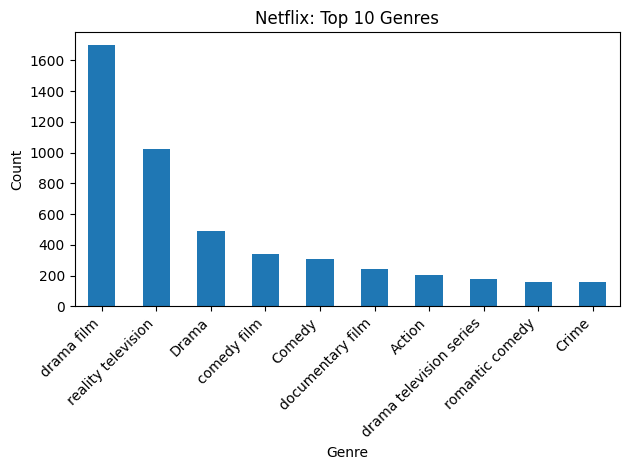

In [10]:
genre_top.plot(kind="bar")
plt.title(f"{PLATFORM}: Top 10 Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 3) Release year patterns

This answers: is the platform more **new-content-driven** or **catalog/library-heavy**?


In [11]:
# Ensure Year is numeric
platform_df["Year"] = pd.to_numeric(platform_df["Year"], errors="coerce")

platform_df["Year"].describe()

count    5666.000000
mean     2015.305860
std         7.277102
min      1954.000000
25%      2015.000000
50%      2018.000000
75%      2019.000000
max      2021.000000
Name: Year, dtype: float64

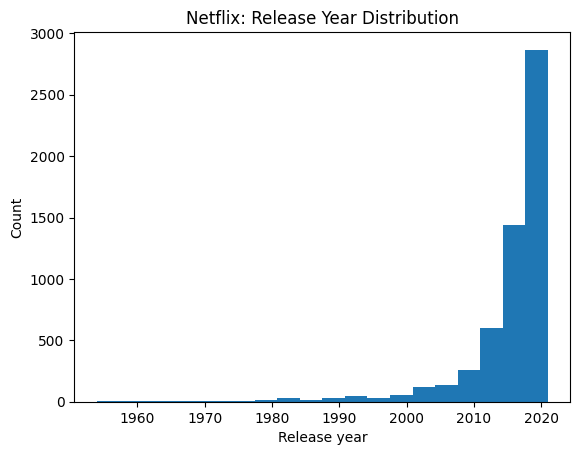

In [12]:
platform_df["Year"].dropna().plot(kind="hist", bins=20)
plt.title(f"{PLATFORM}: Release Year Distribution")
plt.xlabel("Release year")
plt.ylabel("Count")
plt.show()


## 4) Optional: score distributions (IMDb / Rotten Tomatoes)

These fields may have missing values. Use them as supporting context, not the sole conclusion.


IMDb non-null: 5006


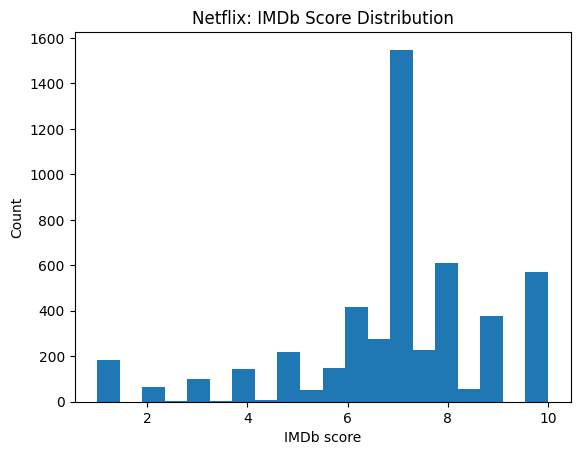

RottenTomatoes_Score non-null: 5666


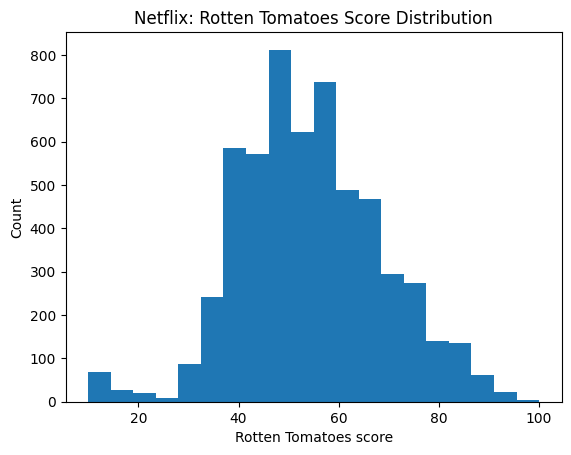

In [13]:
# IMDb distribution
imdb = pd.to_numeric(platform_df["IMDb"], errors="coerce")
print("IMDb non-null:", imdb.notna().sum())

imdb.dropna().plot(kind="hist", bins=20)
plt.title(f"{PLATFORM}: IMDb Score Distribution")
plt.xlabel("IMDb score")
plt.ylabel("Count")
plt.show()

# Rotten Tomatoes distribution
rt = pd.to_numeric(platform_df["RottenTomatoes_Score"], errors="coerce")
print("RottenTomatoes_Score non-null:", rt.notna().sum())

rt.dropna().plot(kind="hist", bins=20)
plt.title(f"{PLATFORM}: Rotten Tomatoes Score Distribution")
plt.xlabel("Rotten Tomatoes score")
plt.ylabel("Count")
plt.show()


## 5) Translate charts into a platform “content identity” paragraph

Use this template (4–6 sentences):

> Based on the **genre mix** and **release year distribution**, *{PLATFORM}* appears to focus on ________.  
> The platform’s catalog is characterized by ________ (e.g., dominant genres, movie vs TV balance).  
> The release year chart suggests ________ (new vs legacy content).  
> (Optional) Score distributions suggest ________ (but note missing data).  
> Overall, the platform’s content identity can be described as ________.

State a claim + evidence:
- Claim: “Netflix is broad-appeal and modern-content heavy…”
- Evidence: “Top genres are X/Y; release years cluster after 2015…”


# In-Session Exercise (20 min)

1) Pick a platform: **Netflix / Hulu / Prime Video / Disney+**  
2) Filter to that platform  
3) Generate **two platform-focused charts**:
- Genre mix (top 10)
- Release year histogram
- Movie vs TV bar chart
- Rating/Age distribution (optional)
4) Write **1–2 bullet insights** per chart

**Stretch goal:** compare your platform’s release year pattern to another platform (just visually).


In [14]:
# Helper: one function to run the core analysis quickly
def analyze_platform(platform_name: str, top_n_genres: int = 10):
    sdf = df_long[df_long["platform"] == platform_name].copy()
    sdf["Year"] = pd.to_numeric(sdf["Year"], errors="coerce")

    # 1) Type mix
    type_counts = sdf["Type"].value_counts()
    display(type_counts)
    type_counts.plot(kind="bar")
    plt.title(f"{platform_name}: Movie vs TV (count)")
    plt.xlabel("Type")
    plt.ylabel("Count")
    plt.show()

    # 2) Genres
    genre_top = top_genres(sdf, top_n=top_n_genres)
    display(genre_top)
    genre_top.plot(kind="bar")
    plt.title(f"{platform_name}: Top {top_n_genres} Genres")
    plt.xlabel("Genre")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    # 3) Year
    sdf["Year"].dropna().plot(kind="hist", bins=20)
    plt.title(f"{platform_name}: Release Year Distribution")
    plt.xlabel("Release year")
    plt.ylabel("Count")
    plt.show()

Type
movie      4113
tv_show    1831
Name: count, dtype: int64

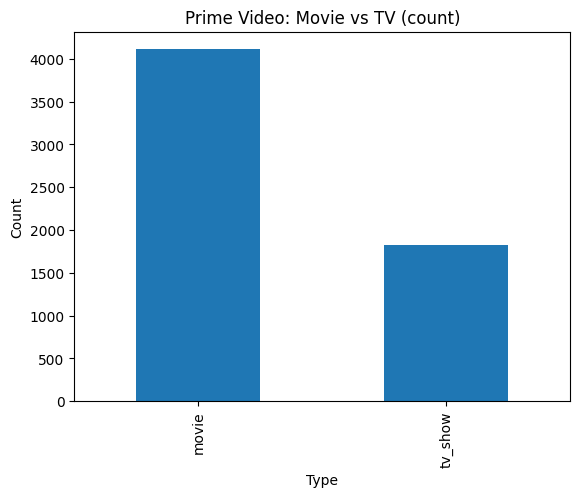

Genre
drama film            2521
reality television    1366
comedy film            347
action film            315
thriller film          219
crime film             211
horror film            209
documentary film       203
romance film           176
comedy drama           165
Name: count, dtype: int64

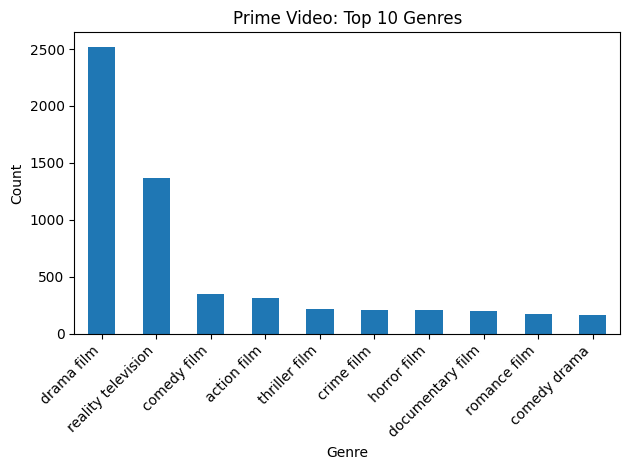

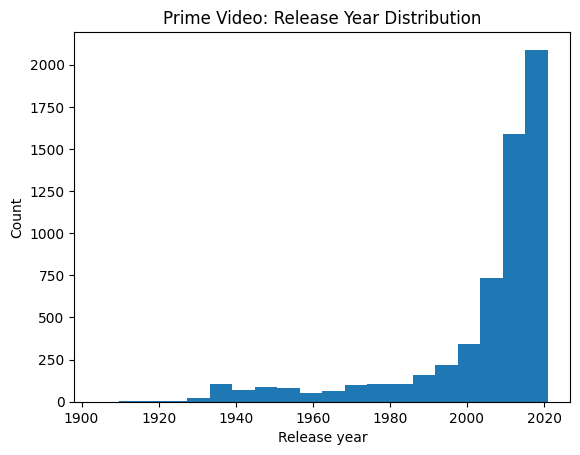

In [15]:
analyze_platform("Prime Video")

Type
tv_show    1621
movie      1047
Name: count, dtype: int64

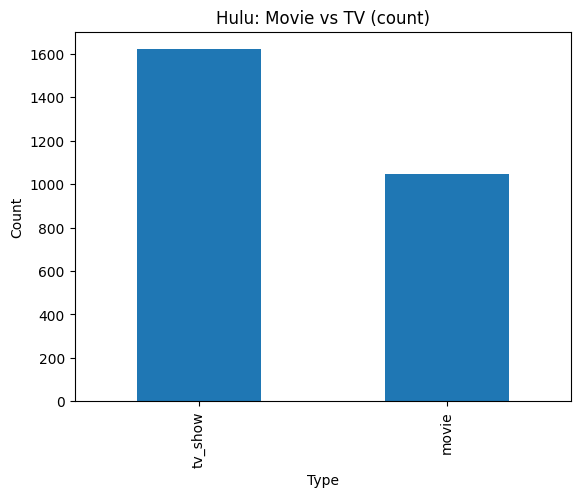

Genre
reality television                984
drama film                        552
drama television series           150
comedy film                       136
action film                       108
documentary film                  107
thriller film                      96
comedy drama                       90
horror film                        90
LGBT-related television series     77
Name: count, dtype: int64

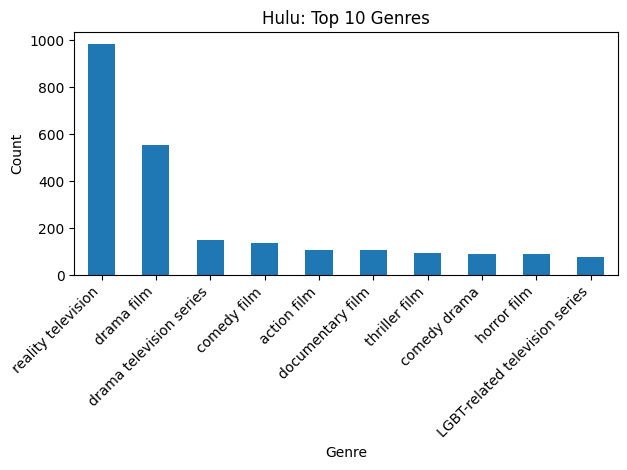

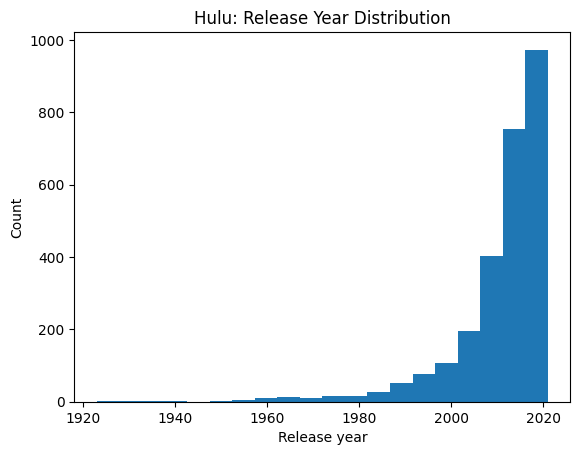

In [16]:
analyze_platform("Hulu")

Type
movie      922
tv_show    351
Name: count, dtype: int64

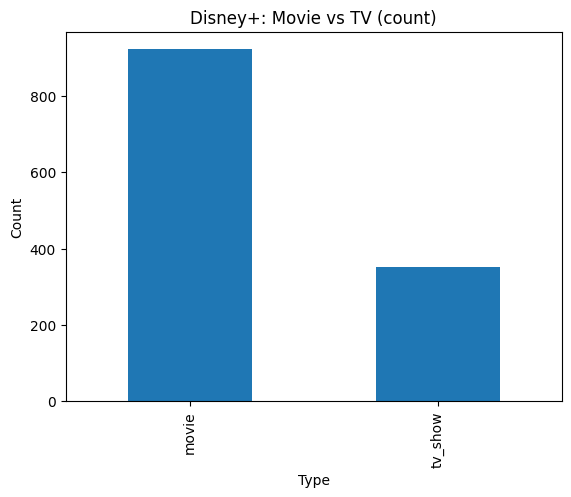

Genre
drama film              585
reality television      257
comedy film             137
fantasy film             99
children's film          74
adventure film           72
action film              65
science fiction film     59
documentary film         48
musical film             43
Name: count, dtype: int64

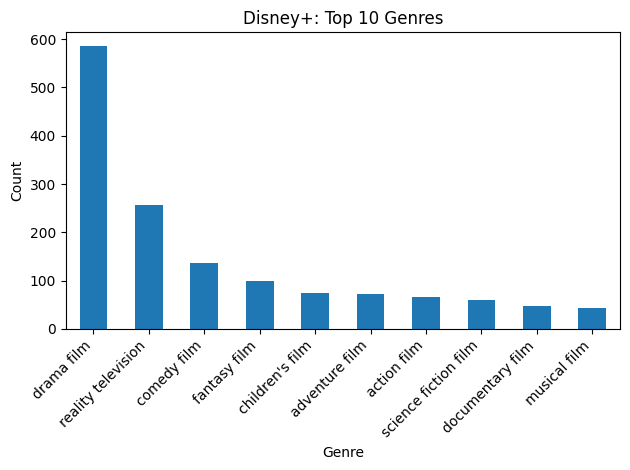

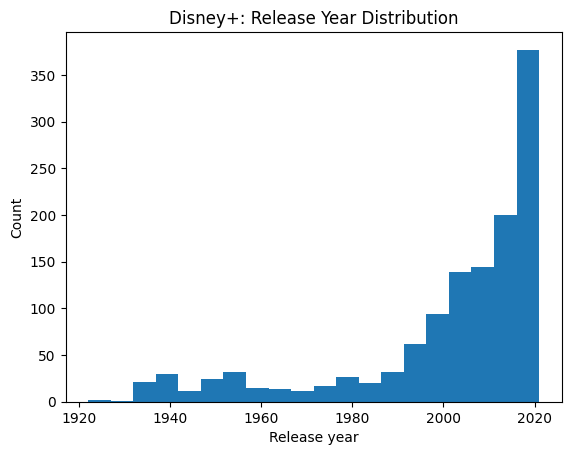

In [18]:
analyze_platform("Disney+")